# Load packages

In [27]:
# -------------------------
# Standard library
# -------------------------
import os
import glob
import time
import re
import warnings
import logging
import gc
from datetime import datetime, timedelta
from pathlib import Path

# -------------------------
# Numerical / scientific
# -------------------------
import numpy as np
import pandas as pd
import xarray as xr
import gsw
from netCDF4 import Dataset

from scipy.stats import linregress, median_abs_deviation, norm
from tqdm import tqdm

# -------------------------
# Machine learning / stats
# -------------------------
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.exceptions import InconsistentVersionWarning

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.nonparametric.smoothers_lowess import lowess

# -------------------------
# Plotting
# -------------------------
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import ticker, dates, patches
from matplotlib.colors import LogNorm
import seaborn as sns
import cmocean as cmo

import cartopy
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# Set matplotlib parameters
mpl.rcParams['figure.facecolor'] = '1'
mpl.rcParams['mathtext.default'] = 'regular'

# Set font parameters
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 10}
mpl.rc('font', **font)

# Data Processing

## Define directories

In [2]:
resdir = f'../DATA'
figdir = f'../FINAL_FIGURES'

# This loads in a biomes file from Fay & McKinley 2014 - if you wish to look at regional variability
biomes = xr.open_dataset(f'{resdir}/Time_Varying_Biomes_25KM.nc').MeanBiomes

# Plots

## Define functions for plotting

In [13]:
def biome_to_slope(biome):
    if np.isnan(biome):
        return np.nan
    else:
        return lookup_array[int(biome)]
        
def calculate_bias(x, y):
    m = ~np.isnan(x) & ~np.isnan(y)
    x = np.log10(x[m])
    y = np.log10(y[m])

    return 10**(np.sum(x - y)/len(x))

# -------------------------------------------------------------------
# Helper: SCI calculation (unchanged)
# -------------------------------------------------------------------
def final_sci(monthly_counts, biome_number=None):
    monthly_counts = np.array(monthly_counts)
    n_months = np.count_nonzero(monthly_counts)

    if biome_number in [1, 8, 17]:  # ice biomes
        coverage = n_months / 8
        h_max = np.log2(8)
    else:
        coverage = n_months / 12
        h_max = np.log2(12)

    total = monthly_counts.sum()
    if total == 0:
        return np.nan, np.nan, np.nan

    p = monthly_counts / total
    p = p[p > 0]
    h = -np.sum(p * np.log2(p))
    entropy_score = h / h_max
    entropy_score = max(entropy_score, 0.0)
    sci = max(np.mean([coverage, entropy_score]), 0.0)

    return sci, coverage, entropy_score


# -------------------------------------------------------------------
# Helper: choose Newey–West lag (annual data)
# -------------------------------------------------------------------
def choose_nw_lag(n, cap_small=True):
    if n <= 3:
        return 0
    bw = int(np.floor(4 * (n / 100.0) ** (2.0 / 9.0)))
    if cap_small:
        bw = min(max(bw, 1), 3)  # for annual data, 1–3 is typical
    return bw


# -------------------------------------------------------------------
# OLS with centered time and Newey–West correction
# -------------------------------------------------------------------
def run_wls_newey_west_centered(x_years, y, weights=None, maxlags="auto"):
    """
    WLS regression on centered time axis with Newey–West (HAC) SEs.

    Parameters
    ----------
    x_years : array-like
        Year values (e.g. 2005, 2006, ...).
    y : array-like
        Annual mean values.
    weights : array-like or None
        Weights for WLS (e.g. sqrt(profile counts) per year).
        If None, ordinary least squares is used.
    maxlags : "auto" or int
        Newey–West maxlags. If "auto", choose_nw_lag(n) is used.

    Returns
    -------
    slope, intercept, slope_se, pval, r_squared, fval, n, L, r1, resid
    """
    x0 = np.asarray(x_years, dtype=float)
    x0 = x0 - x0.min()  # center years at 0
    X = sm.add_constant(x0.reshape(-1, 1))
    y = np.asarray(y, dtype=float)
    n = len(y)

    if weights is None:
        model = sm.OLS(y, X)
    else:
        w = np.asarray(weights, dtype=float)
        if w.shape != y.shape:
            raise ValueError("weights must have same shape as y")
        model = sm.WLS(y, X, weights=w)

    fit = model.fit()

    # Determine lag and compute HAC covariance
    L = choose_nw_lag(n) if maxlags == "auto" else int(maxlags)
    fit_hac = fit.get_robustcov_results(cov_type="HAC", maxlags=L, use_correction=True)

    intercept = fit_hac.params[0]
    slope     = fit_hac.params[1]
    slope_se  = fit_hac.bse[1]
    pval      = fit_hac.pvalues[1]
    r_squared = fit.rsquared
    fval      = fit.fvalue

    resid = fit.resid
    r1 = np.nan
    if n >= 3:
        r1 = np.corrcoef(resid[:-1], resid[1:])[0, 1]

    return slope, intercept, slope_se, pval, r_squared, fval, n, L, r1, resid

def detection_years_needed(slope, resid, phi=None, const=3.3):
    """
    Estimate record length (years) needed to detect a trend given noise and autocorrelation.
    Weatherhead et al. (1998) formulation.
    """
    if not np.isfinite(slope) or slope == 0 or resid.size < 3:
        return np.nan, np.nan, np.nan

    if phi is None:
        phi = np.corrcoef(resid[:-1], resid[1:])[0, 1]
    phi = np.clip(phi, -0.99, 0.99)
    sigma_N = np.std(resid, ddof=1)

    # Weatherhead et al. 1998, expressed in years for an annual series
    A = const * sigma_N / abs(slope) * np.sqrt((1 + phi) / (1 - phi))
    Ndet = A ** (2.0 / 3.0)

    return float(Ndet), float(phi), float(sigma_N)


# -------------------------------------------------------------------
# Main function
# -------------------------------------------------------------------
def calculate_trends_biomes(
    ds,
    var,
    quality_control=False,
    normalise=False,
    sci_criteria=0.7,
    return_data=False,
    nw_maxlags="auto",
):
    """
    Calculate annual biome-level trends using OLS + Newey–West HAC SEs
    and Weatherhead detection time.
    """
    biomes = []
    annual_series = {}

    for i in range(1, 18):
        grp = ds.loc[ds.BIOME == i].copy()
        if grp.empty:
            biomes.append(pd.Series([np.nan] * 14 + [i]))
            continue

        if quality_control:
            lower = grp[var].quantile(0.01)
            upper = grp[var].quantile(0.99)
            grp = grp[(grp[var] >= lower) & (grp[var] <= upper)]

        grp['year'] = grp.DATETIME.dt.year
        grp['month'] = grp.DATETIME.dt.month

        # Apply SCI coverage screening
        valid_years = []
        sci_data = []
        for year, g in grp.groupby('year'):
            monthly_counts = g['month'].value_counts().reindex(range(1, 13), fill_value=0).values
            sci, coverage, entropy = final_sci(monthly_counts, biome_number=i)
            sci_data.append(sci)
            if (sci is not None) and (sci >= sci_criteria):
                valid_years.append(year)

        grp = grp[grp['year'].isin(valid_years)]
        if grp.empty:
            biomes.append(pd.Series([np.nan] * 14 + [i]))
            continue

        # Aggregate to annual mean and counts
        annual_mean = grp.set_index('DATETIME').resample('YE')[var].mean()
        annual_cnt  = grp.set_index('DATETIME').resample('YE')[var].count()

        # Convert index to years
        annual_mean.index = annual_mean.index.year
        annual_cnt.index  = annual_cnt.index.year

        # Drop years with NaN means and align counts
        annual_mean = annual_mean.dropna()
        annual_cnt  = annual_cnt.loc[annual_mean.index]

        if annual_mean.size < 3:
            biomes.append(pd.Series([np.nan] * 14 + [i]))
            continue

        y     = annual_mean.values.astype(float)
        years = annual_mean.index.values.astype(float)

        # Weights: sqrt(profile counts) per year
        w = annual_cnt.values.astype(float)
        # Ensure positive, finite weights
        w = np.where(np.isfinite(w) & (w > 0), w, np.nan)
        if np.all(np.isnan(w)):
            biomes.append(pd.Series([np.nan] * 14 + [i]))
            continue
        weights = np.sqrt(w)

        if normalise:
            mean_y = np.nanmean(y)
            if not np.isfinite(mean_y) or mean_y <= 0:
                biomes.append(pd.Series([np.nan] * 14 + [i]))
                continue
            y = y / mean_y


        # Fit WLS + HAC (centered time), weighted by sqrt(profile counts)
        slope, intercept, slope_se, pval, r2, fval, n, L, r1, resid = \
            run_wls_newey_west_centered(
                years, y, weights=weights, maxlags=nw_maxlags
            )


        # Detection time (Weatherhead)
        Ndet, phi, sigma_N = detection_years_needed(slope, resid)
        detection_feasible = (n >= Ndet) if np.isfinite(Ndet) else np.nan

        annual_series[i] = pd.Series(y, index=years)

        res = pd.Series([
            slope,
            intercept,
            slope_se,
            pval,
            r2,
            fval,
            n,
            L,
            r1,
            sigma_N,
            Ndet,
            detection_feasible,
            np.mean(sci_data),
            np.std(sci_data),
            i
        ])
        biomes.append(res)

    biomes_df = pd.concat(biomes, axis=1).T
    biomes_df.columns = [
        'slope',
        'intercept',
        'slope_se_hac',
        'p_value_hac',
        'r_squared',
        'f_value',
        'n_years',
        'nw_lag_used',
        'lag1_autocorr',
        'sigma_noise',
        'years_needed_detect',
        'detection_feasible',
        'sci_mean',
        'sci_std',
        'biome'
    ]

    if normalise:
        biomes_df['slope'] = biomes_df['slope'] * 100.0  # express as %/yr

    return (biomes_df, annual_series) if return_data else biomes_df

def run_sci_sensitivity_analysis(
    ds,
    var,
    normalise=False,
    quality_control=False,
    thresholds=None,
    nw_maxlags="auto"):
    """
    Run calculate_trends_biomes() over a range of SCI thresholds and
    return stacked results.

    Parameters
    ----------
    ds : xarray.Dataset
        Input dataset with NPP and biome labels.
    var : str
        Variable name (e.g. 'NPP_ANNUAL').
    normalise : bool, optional
        If True, normalise each biome time series by its mean before trend fitting.
    quality_control : bool, optional
        If True, apply additional 1–99th percentile trimming before trend fitting.
    thresholds : iterable of float, optional
        SCI thresholds to test. If None, use np.arange(0.6, 0.951, 0.05).
    nw_maxlags : "auto" or int, optional
        Newey–West maxlags argument passed to calculate_trends_biomes().

    Returns
    -------
    pandas.DataFrame
        Multi-indexed by (sci_criteria, biome) with trend diagnostics
        (slope, SE, p-value, etc.) for each threshold.
    """
    if thresholds is None:
        thresholds = np.arange(0.6, 0.95, 0.05)

    all_results = []

    for sci in thresholds:
        res = calculate_trends_biomes(
            ds,
            var,
            quality_control=quality_control,
            normalise=normalise,
            sci_criteria=sci,
            return_data=False,
            nw_maxlags=nw_maxlags,
        )
        res = res.copy()
        res["sci_criteria"] = sci
        all_results.append(res)

    df = pd.concat(all_results, axis=0, ignore_index=True)
    df.set_index(["sci_criteria", "biome"], inplace=True)
    return df
    

def compare_trends(df1, df2, alpha=0.05):
    """
    Compare trends between two dataframes and classify per-biome results.

    Parameters:
    - df1, df2: pandas DataFrames with 'slope' and 'slope_std_err' columns.
                Index should correspond to biomes (same in both).
    - alpha: significance level for Z-test (default 0.05)

    Returns:
    - DataFrame with classification results per biome
    """
    results = []

    classification_map = {
    'Not Significant & Same Sign': 4,   
    'Significant & Same Sign': 3,       
    'Not Significant & Opposite Sign': 2,   
    'Significant & Opposite Sign': 1, 
    'Unclassified': 0                   
}

    for biome in df1.index:
        slope1 = df1.loc[biome, 'slope']
        se1 = df1.loc[biome, 'slope_se_hac']
        slope2 = df2.loc[biome, 'slope']
        se2 = df2.loc[biome, 'slope_se_hac']

        # Z-test for difference in slopes
        if np.isfinite(se1) and np.isfinite(se2) and (se1 > 0) and (se2 > 0):
            z = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
            pval = 2 * (1 - norm.cdf(np.abs(z)))
        else:
            z = np.nan
            pval = np.nan

        # Sign agreement
        same_sign = np.sign(slope1) == np.sign(slope2)

        # Classification logic
        if np.isnan(pval):
            classification = 'Unclassified'
        elif pval < alpha and same_sign:
            classification = 'Significant & Same Sign'
        elif pval < alpha and not same_sign:
            classification = 'Significant & Opposite Sign'
        elif pval >= alpha and same_sign:
            classification = 'Not Significant & Same Sign'
        elif pval >= alpha and not same_sign:
            classification = 'Not Significant & Opposite Sign'

        classification_code = classification_map[classification]

        results.append({
            'slope1': slope1,
            'slope2': slope2,
            'slope_diff': slope1 - slope2,
            'z_value': z,
            'p_value': pval,
            'sign_agreement': same_sign,
            'classification': classification,
            'classification_code': classification_code
        })

    return pd.DataFrame(results, index=df1.index)

plot_colors = ['midnightblue', 'peru', 'darkcyan', 'maroon', 'darkgreen', 'darkorchid', 'grey', 'black']

## Main Figures

### Figure 1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


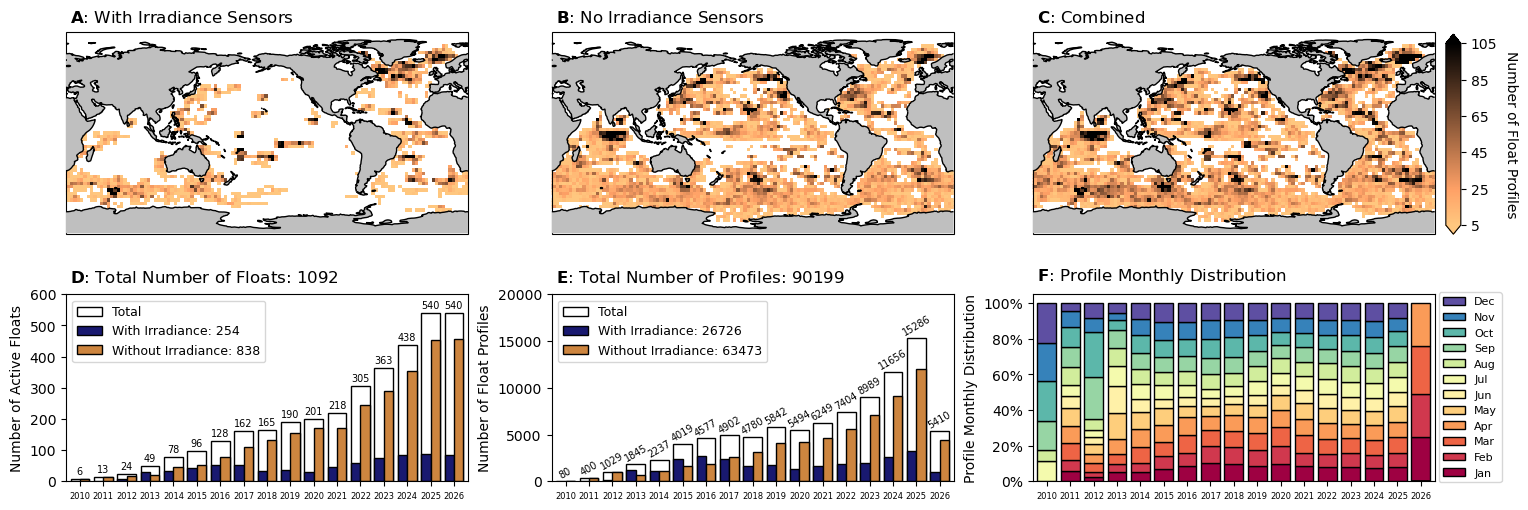

In [22]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.concat(
    [ds1a, ds1b],
    dim="N_PROF",
    coords="minimal",
    data_vars="all",
    compat="override",
    join="outer",
)

df1a = ds1a[['LATITUDE', 'LONGITUDE', 'DATETIME', 'CHLA_INT', 'CPHYTO_INT']].to_dataframe().dropna(subset=['CHLA_INT', 'CPHYTO_INT']).reset_index()
df1b = ds1b[['LATITUDE', 'LONGITUDE', 'DATETIME', 'CHLA_INT', 'CPHYTO_INT']].to_dataframe().dropna(subset=['CHLA_INT', 'CPHYTO_INT']).reset_index()
df1 = ds1[['LATITUDE', 'LONGITUDE', 'DATETIME', 'CHLA_INT', 'CPHYTO_INT']].to_dataframe().dropna(subset=['CHLA_INT', 'CPHYTO_INT']).reset_index()

fig = plt.figure(figsize=[15, 5], constrained_layout=True)
gs = plt.GridSpec(2, 3, figure=fig, height_ratios=[1, 0.75])

ax0 = fig.add_subplot(gs[:1, :1], projection=ccrs.PlateCarree(central_longitude=-155))
ax0.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax0.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax0.set_global()

ax1 = fig.add_subplot(gs[:1, 1:2], projection=ccrs.PlateCarree(central_longitude=-155))
ax1.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax1.set_global()

ax2 = fig.add_subplot(gs[:1, 2:], projection=ccrs.PlateCarree(central_longitude=-155))
ax2.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax2.set_global()

# Define latitude and longitude bins
lat_bins = np.arange(-90, 93, 3)
lon_bins = np.arange(-180, 183, 3)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1a.LONGITUDE.values, 
                                            df1a.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap1 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap1 = heatmap1.where(heatmap1 != 0, np.nan)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1b.LONGITUDE.values, 
                                            df1b.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap2 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap2 = heatmap2.where(heatmap2 != 0, np.nan)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1.LONGITUDE.values, 
                                            df1.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap3 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap3 = heatmap3.where(heatmap3 != 0, np.nan)

im = heatmap1.T.plot(ax=ax0, vmin=5, vmax=105, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())
im = heatmap2.T.plot(ax=ax1, vmin=5, vmax=105, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())
im = heatmap3.T.plot(ax=ax2, vmin=5, vmax=105, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())

cbar_ax = fig.add_axes([0.96, 0.54, 0.01, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax, extend='both', ticks=np.arange(5, 125, 20))
cbar.set_label('Number of Float Profiles', rotation=270, labelpad=15)
#cbar.ax.yaxis.set_ticks_position('left')
#cbar.ax.yaxis.set_label_position('left')

ax0.text(0.01, 1.05, r'$\bf{A}$: With Irradiance Sensors', transform=ax0.transAxes, fontsize=12)
ax1.text(0.01, 1.05, r'$\bf{B}$: No Irradiance Sensors', transform=ax1.transAxes, fontsize=12)
ax2.text(0.01, 1.05, r'$\bf{C}$: Combined', transform=ax2.transAxes, fontsize=12)

ax3 = fig.add_subplot(gs[1:, :1])
ax4 = fig.add_subplot(gs[1:, 1:2])
ax5 = fig.add_subplot(gs[1:, 2:])

index = np.arange(2010, 2027, 1)

y1 = np.squeeze(df1a.groupby(df1a.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)
y2 = np.squeeze(df1b.groupby(df1b.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)
y3 = np.squeeze(df1.groupby(df1.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)

y4 = np.squeeze(df1a.groupby(df1a.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)
y5 = np.squeeze(df1b.groupby(df1b.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)
y6 = np.squeeze(df1.groupby(df1.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)

y = np.squeeze(df1.groupby([df1.DATETIME.dt.year, df1.DATETIME.dt.month]).count()[['N_PROF']])
y = y.unstack()
normalized_y = y.div(y.sum(axis=1), axis=0) #* 100

x = np.arange(len(y1))  # the label locations
width = 0.4  # the width of the bars

bars3 = ax3.bar(x, y3, width*2, color='w', edgecolor='k', label='Total')
bars1 = ax3.bar(x - width/2, y1, width, label=f'With Irradiance: {len(np.unique(df1a.FLOAT))}', color=plot_colors[0], edgecolor='k')
bars2 = ax3.bar(x + width/2, y2, width, label=f'Without Irradiance: {len(np.unique(df1b.FLOAT))}', color=plot_colors[1], edgecolor='k')

bars3 = ax4.bar(x, y6, width*2, color='w', edgecolor='k', label='Total')
bars1 = ax4.bar(x - width/2, y4, width, label=f'With Irradiance: {df1a.shape[0]}', color=plot_colors[0], edgecolor='k')
bars2 = ax4.bar(x + width/2, y5, width, label=f'Without Irradiance: {df1b.shape[0]}', color=plot_colors[1], edgecolor='k')

cmap = plt.colormaps.get_cmap('Spectral')(np.linspace(0, 1, 12))

normalized_y.plot.bar(ax=ax5, width=width*2, color=cmap, edgecolor='k', stacked=True, legend=False)

ax3.legend(loc=2, fontsize=9)
ax4.legend(loc=2, fontsize=9)

ax3.set_ylabel('Number of Active Floats')
ax4.set_ylabel('Number of Float Profiles')
ax5.set_ylabel('Profile Monthly Distribution')
ax5.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax5.set_xlabel('')

ax3.set_xticks(x)
ax4.set_xticks(x)
ax5.set_xticks(x)

ax3.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'], fontsize=6, rotation=0)
ax4.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'], fontsize=6, rotation=0)
ax5.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'], fontsize=6, rotation=0)

ax3.set_ylim(0, 600)
ax4.set_ylim(0, 20000)

ax3.set_xlim(-0.6, 16.6)
ax4.set_xlim(-0.6, 16.6)
ax5.set_xlim(-0.6, 16.6)

ax3.text(0.01, 1.05, r'$\bf{{D}}$:'+f' Total Number of Floats: {len(np.unique(df1.FLOAT))}', va='bottom', transform=ax3.transAxes, fontsize=12)
ax4.text(0.01, 1.05, r'$\bf{{E}}$:'+f' Total Number of Profiles: {np.nansum(y6):.0f}', va='bottom', transform=ax4.transAxes, fontsize=12)
ax5.text(0.01, 1.05, r'$\bf{F}$: Profile Monthly Distribution', va='bottom', transform=ax5.transAxes, fontsize=12)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
legend_patches = [patches.Patch(facecolor=color, edgecolor='k', label=label) for label, color in zip(months, cmap)]
legend_patches = legend_patches[::-1]
months = months[::-1]
ax5.legend(handles=legend_patches, labels=months, loc='upper right', bbox_to_anchor=(1.18, 1.04), fontsize=8)

for i in range(len(y3)):
    ax3.text(x[i], y3[i]+15, f'{y3[i]:.0f}', fontsize=7, ha='center')

for i in range(len(y6)):
    ax4.text(x[i], y6[i]+300, f'{y6[i]:.0f}', fontsize=7, ha='center', rotation=30)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_01.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_01.eps", bbox_inches='tight', dpi=300)

### Figure 2

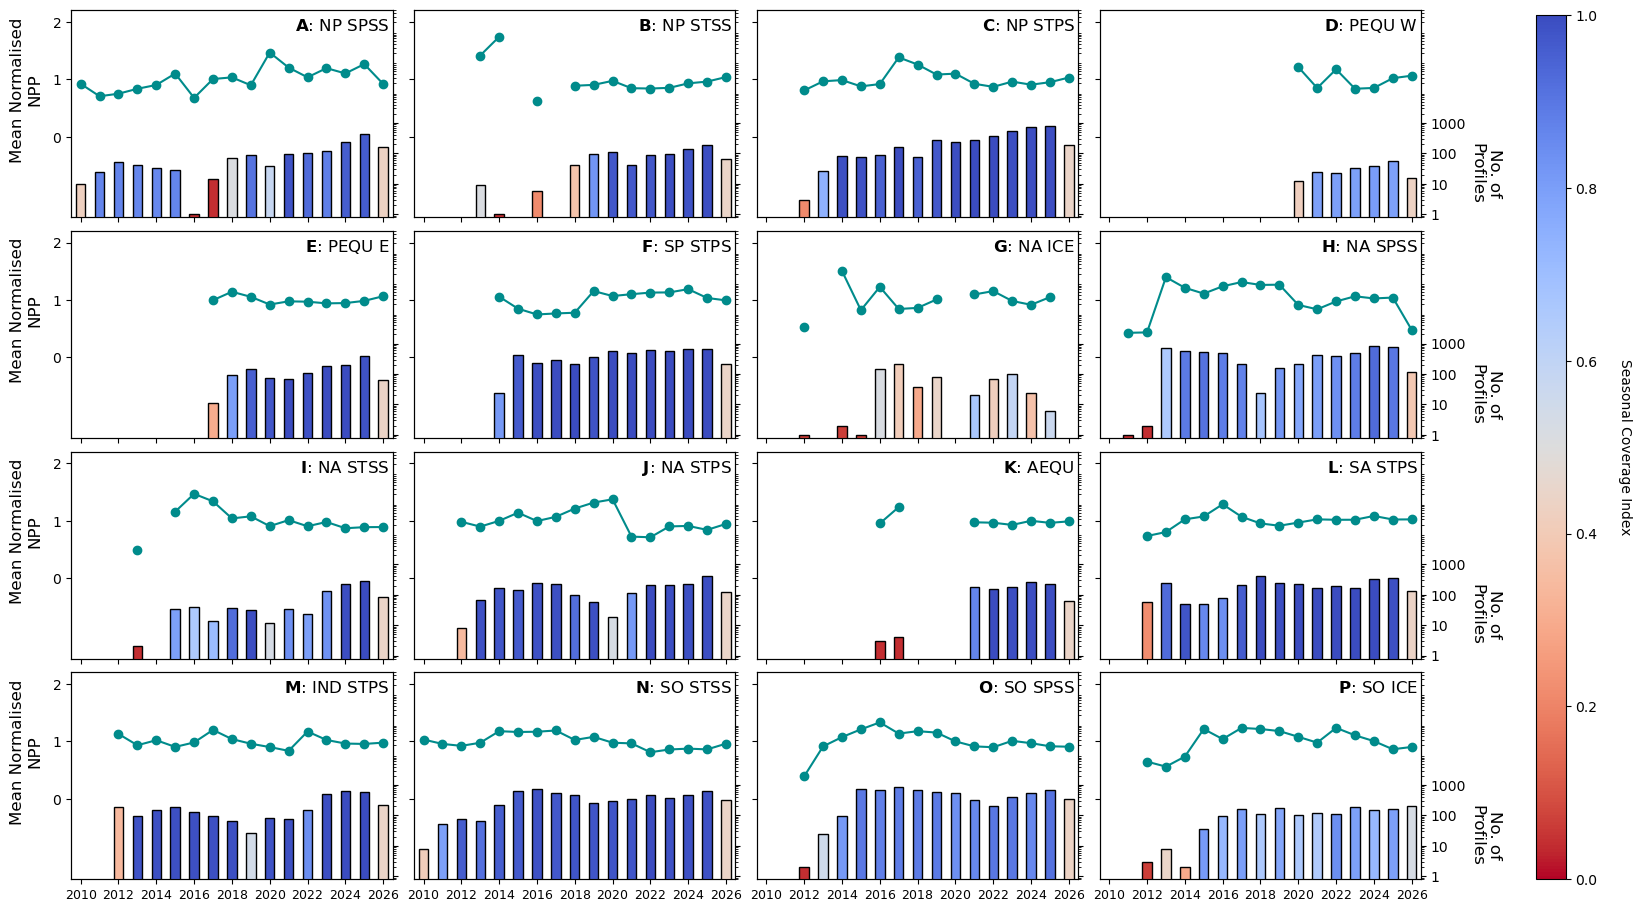

In [5]:
#Define biome names
bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS',
         'NA ICE', 'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.concat(
    [ds1a, ds1b],
    dim="N_PROF",
    coords="minimal",
    data_vars="all",
    compat="override",
    join="outer",
)

ds1 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']]

names = [bname[1:]]
biomes = np.arange(2, 18, 1)
letters = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Create figure and GridSpec
fig = plt.figure(figsize=[15, 9], constrained_layout=True)
gs = plt.GridSpec(4, 4, figure=fig)

# Define the axes in a 4x4 grid
axes = [fig.add_subplot(gs[i, j]) for i in range(4) for j in range(4)]
twin_axes = [ax.twinx() for ax in axes]
#sci_data = []

for idx, (b, ax, twin_ax) in enumerate(zip(biomes, axes, twin_axes)):

    df1 = ds1.where(ds1.BIOME == b, drop=True).to_dataframe().reset_index(drop=True).dropna()
    df1 = df1.set_index(pd.DatetimeIndex(df1.DATETIME)).drop(columns=['BIOME', 'DATETIME'])
    filtered_df = df1.copy()
    for col in df1.columns:
        lower = df1[col].quantile(0.025)
        upper = df1[col].quantile(0.975)
        filtered_df = filtered_df[(filtered_df[col] >= lower) & (filtered_df[col] <= upper)]
    df1m = filtered_df.groupby(filtered_df.index.year).mean().reindex(np.arange(2010, 2027, 1))
    df1m = df1m / df1m.mean()
    df1c = filtered_df.groupby(filtered_df.index.year).count().reindex(np.arange(2010, 2027, 1))
    monthly_counts = (filtered_df.groupby([filtered_df.index.year, filtered_df.index.month]).size().unstack(fill_value=0))
    monthly_counts = monthly_counts.reindex(columns=np.arange(1, 13), fill_value=0)

    results = monthly_counts.apply(lambda row: final_sci(row, biome_number=b), axis=1)

    results_df = pd.DataFrame(results.tolist(), index=monthly_counts.index, columns=['SCI', 'Coverage', 'Entropy'])
    sci_per_year = results_df['SCI']
    cov = results_df['Coverage']
    ent = results_df['Entropy']

    df1m.reset_index(drop=True).plot(ax=ax, marker='o', color=colors[2], legend=False)
    sci_aligned = sci_per_year.reindex(df1c.index, fill_value=0)  # or fill_value=np.nan
    sci_vals = sci_aligned.reset_index(drop=True).values
    nor = mpl.colors.Normalize(vmin=0, vmax=1, clip=True)

    cmap = mpl.cm.coolwarm_r  # or any other matplotlib colormap

    bar_colors = cmap(nor(sci_vals))
    df1c.reset_index(drop=True).WESTBERRY_CBPM_INT.plot.bar(
    ax=twin_ax, 
    color=bar_colors, 
    edgecolor='k', 
    width=0.5)

    ax.set_ylim(-1.4, 2.2)
    ax.set_xlabel('')
    ax.set_xticks(np.arange(0, 18, 2))
    ax.set_xticklabels(np.arange(2010, 2028, 2), fontsize=9)
    t = f'$\\mathbf{{{letters[b-2]}}}$'
    t2 = f'{names[0][b-2]}'#\nSCI = {sci_per_year.mean():.2f}±{sci_per_year.std():.2f}'
    #ax.set_title(t + ': ' + t2, fontsize=12)
    ax.text(0.99, 0.90, t + ': ' + t2, transform=ax.transAxes, fontsize=12, ha='right')
    twin_ax.set_yscale('log')
    twin_ax.set_ylim(0.8, 5000000)
    ax.set_yticks(np.arange(0, 3, 1))
    twin_ax.set_yticks([1, 10, 100, 1000])
    twin_ax.set_yticklabels(['1', '10', '100', '1000'])

    # Turn off x-ticklabels for all but the bottom row
    if idx < 12:
        ax.set_xticklabels([])

    # Turn off y-ticklabels for all but the first column
    if idx % 4 != 0:
        ax.set_yticklabels([])

    # Turn off twin_ax y-ticklabels for all but the last column
    if (idx + 1) % 4 != 0:
        twin_ax.set_yticklabels([])
        
axes[0].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[0].transAxes, rotation=90, ha='center')
axes[4].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[4].transAxes, rotation=90, ha='center')
axes[8].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[8].transAxes, rotation=90, ha='center')
axes[12].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[12].transAxes, rotation=90, ha='center')

twin_axes[3].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[3].transAxes, rotation=270, ha='center')
twin_axes[7].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[7].transAxes, rotation=270, ha='center')
twin_axes[11].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[11].transAxes, rotation=270, ha='center')
twin_axes[15].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[15].transAxes, rotation=270, ha='center')

cbar_ax = fig.add_axes([1.02, 0.03, 0.02, 0.96])  # narrow vertical bar on right

# Create the colorbar in that axis
sma = plt.cm.ScalarMappable(cmap=cmap, norm=nor)
sma.set_array([])  # needed for colorbar to work
cbar = fig.colorbar(sma, cax=cbar_ax)
cbar.set_label('Seasonal Coverage Index', rotation=270, labelpad=25)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_02.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_02.eps", bbox_inches='tight', dpi=300)

### Figure 3

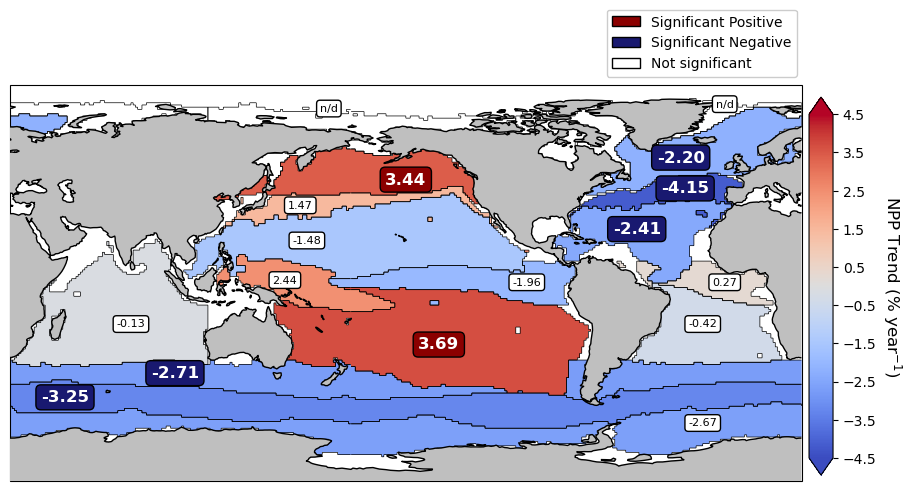

In [11]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.concat(
    [ds1a, ds1b],
    dim="N_PROF",
    coords="minimal",
    data_vars="all",
    compat="override",
    join="outer",
)

threshold_date = np.datetime64('2026-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
cbpm_biomes = calculate_trends_biomes(ds_cbpm, 'WESTBERRY_CBPM_INT', quality_control=False, normalise=True, sci_criteria=0.7)

biomes = xr.open_dataset(f'{resdir}/Mean_Biomes_25KM.nc')
biomes_array = biomes['MeanBiomes'].values
unique_values = np.unique(biomes_array)
unique_values = unique_values[:-1]
lats = biomes['lat'].values
lons = biomes['lon'].values
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

cbpm_dict = dict(zip(np.arange(1, 18), cbpm_biomes.iloc[:, 0].values))

max_biome = int(max(cbpm_dict)) + 1
lookup_array = np.full(max_biome, np.nan)
for biome, slope in cbpm_dict.items():
    lookup_array[int(biome)] = slope
    
cbpm_slopes = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

pos_x = [170, -155, 157, 160, 150, -100, -140, -10, -30, -28, -50, -10, -20, 80, 100, 50, -20]
pos_y = [78, 45, 34, 18, 0, -1, -30, 80, 55, 41, 22.5, -1, -20, -20, -43, -54, -65]
vmin = -4.5
vmax = 4.5

fig = plt.figure(figsize=[8, 6], constrained_layout=True)
gs = plt.GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[:1, :], projection=ccrs.PlateCarree(central_longitude=-155))
ax.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax.set_global()

im = cbpm_slopes.plot(ax=ax, vmin=vmin, vmax=vmax, cmap='coolwarm', add_colorbar=False, transform=ccrs.PlateCarree())
for value in unique_values:
    mask = biomes_array == value
    ax.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

for i in range(17):
    if np.isnan(cbpm_biomes['p_value_hac'][i]):
        ax.text(pos_x[i], pos_y[i], 'n/d', transform=ccrs.PlateCarree(),
                 fontsize=8,  ha='center', zorder=6, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'))
    else:
        if (cbpm_biomes['p_value_hac'][i] > 0.05):
            fontweight='normal'
            fontsize=8
            boxcolor='w'
            fontcolor='k'
        else:
            fontweight='bold'
            fontsize=12
            fontcolor='w'
            if (cbpm_biomes['slope'][i] > 0):
                boxcolor='darkred'
            else: 
                boxcolor='midnightblue'

        ax.text(pos_x[i], pos_y[i], f"{cbpm_biomes['slope'][i]:.2f}", transform=ccrs.PlateCarree(),
                 fontsize=fontsize, color=fontcolor, fontweight=fontweight, ha='center', zorder=6, 
                 bbox=dict(facecolor=boxcolor, edgecolor='k', boxstyle='round'))

legend_axes = fig.add_axes([0.77, 0.85, 0.2, 0.1])

legend_elements = [patches.Patch(facecolor='darkred', edgecolor='k', label='Significant Positive'),
                   patches.Patch(facecolor='midnightblue', edgecolor='k', label='Significant Negative'), 
                   patches.Patch(facecolor='w', edgecolor='k', label='Not significant')]

legend = legend_axes.legend(handles=legend_elements, loc='center', fontsize=10)
legend_axes.axis('off')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)

cbar_ax = fig.add_axes([1.004, 0.18, 0.03, 0.63])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(vmin, vmax+1, 1), extend='both')
cbar.set_label('NPP Trend (% year$^{-1}$)', labelpad=20, rotation=270, fontsize=12)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_03.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_03.eps", bbox_inches='tight', dpi=300)

In [7]:
ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
cbpm_biomes = calculate_trends_biomes(ds_cbpm, 'WESTBERRY_CBPM_INT', quality_control=False, normalise=True, sci_criteria=0.70)
cbpm_biomes

,slope,intercept,slope_se_hac,p_value_hac,r_squared,f_value,n_years,nw_lag_used,lag1_autocorr,sigma_noise,years_needed_detect,detection_feasible,sci_mean,sci_std,biome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,3.443643,0.750364,0.003062,0.000001,0.761426,28.724213,11,2,-0.765786,0.10013,2.302847,True,0.725179,0.304955,2
2,1.465184,0.966914,0.014342,0.35383,0.124497,0.711001,7,2,0.159977,0.091038,8.342213,False,0.741675,0.302772,3
3,-1.478787,1.096044,0.013229,0.287443,0.120598,1.508501,13,2,0.452342,0.168877,15.558642,False,0.913236,0.204709,4
4,2.444122,0.946941,0.025452,0.407758,0.068003,0.218894,5,2,-0.666187,0.156314,4.468745,True,0.735542,0.140662,5
5,-1.963433,1.076089,0.012146,0.157104,0.344484,3.153101,8,2,0.190992,0.073353,6.071044,True,0.890307,0.217747,6
6,3.685167,0.79049,0.011258,0.008384,0.501413,10.056668,12,2,0.153887,0.143044,6.071036,True,0.978091,0.050539,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
8,-2.199595,1.123288,0.007598,0.017739,0.344553,4.731095,11,2,0.40698,0.131799,9.752799,True,0.730235,0.280913,9
9,-4.153933,1.222211,0.006473,0.000361,0.791335,26.546557,9,2,-0.217018,0.090829,3.223583,True,0.757424,0.257556,10


In [8]:
ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
cbpm_biomes = calculate_trends_biomes(ds_cbpm, 'WESTBERRY_CBPM_INT', quality_control=False, normalise=True, sci_criteria=0.70)
cbpm_biomes

,slope,intercept,slope_se_hac,p_value_hac,r_squared,f_value,n_years,nw_lag_used,lag1_autocorr,sigma_noise,years_needed_detect,detection_feasible,sci_mean,sci_std,biome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,3.443643,0.750364,0.003062,0.000001,0.761426,28.724213,11,2,-0.765786,0.10013,2.302847,True,0.725179,0.304955,2
2,1.465184,0.966914,0.014342,0.35383,0.124497,0.711001,7,2,0.159977,0.091038,8.342213,False,0.741675,0.302772,3
3,-1.478787,1.096044,0.013229,0.287443,0.120598,1.508501,13,2,0.452342,0.168877,15.558642,False,0.913236,0.204709,4
4,2.444122,0.946941,0.025452,0.407758,0.068003,0.218894,5,2,-0.666187,0.156314,4.468745,True,0.735542,0.140662,5
5,-1.963433,1.076089,0.012146,0.157104,0.344484,3.153101,8,2,0.190992,0.073353,6.071044,True,0.890307,0.217747,6
6,3.685167,0.79049,0.011258,0.008384,0.501413,10.056668,12,2,0.153887,0.143044,6.071036,True,0.978091,0.050539,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
8,-2.199595,1.123288,0.007598,0.017739,0.344553,4.731095,11,2,0.40698,0.131799,9.752799,True,0.730235,0.280913,9
9,-4.153933,1.222211,0.006473,0.000361,0.791335,26.546557,9,2,-0.217018,0.090829,3.223583,True,0.757424,0.257556,10


In [9]:
ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
cbpm_biomes = calculate_trends_biomes(ds_cbpm, 'WESTBERRY_CBPM_INT', quality_control=False, normalise=False, sci_criteria=0.70)
cbpm_biomes

,slope,intercept,slope_se_hac,p_value_hac,r_squared,f_value,n_years,nw_lag_used,lag1_autocorr,sigma_noise,years_needed_detect,detection_feasible,sci_mean,sci_std,biome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,17.535314,382.091624,1.559205,0.000001,0.761426,28.724213,11,2,-0.765786,50.987075,2.302847,True,0.725179,0.304955,2
2,5.760325,380.139371,5.638542,0.35383,0.124497,0.711001,7,2,0.159977,35.791154,8.342213,False,0.741675,0.302772,3
3,-5.013445,371.585442,4.484829,0.287443,0.120598,1.508501,13,2,0.452342,57.253252,15.558642,False,0.913236,0.204709,4
4,9.136495,353.980712,9.514475,0.407758,0.068003,0.218894,5,2,-0.666187,58.432434,4.468745,True,0.735542,0.140662,5
5,-12.666342,694.197812,7.835435,0.157104,0.344484,3.153101,8,2,0.190992,47.321075,6.071044,True,0.890307,0.217747,6
6,14.144058,303.398518,4.321098,0.008384,0.501413,10.056668,12,2,0.153887,54.901846,6.071036,True,0.978091,0.050539,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
8,-13.051169,666.496334,4.508166,0.017739,0.344553,4.731095,11,2,0.40698,78.202374,9.752799,True,0.730235,0.280913,9
9,-23.976212,705.451569,3.736313,0.000361,0.791335,26.546557,9,2,-0.217018,52.426076,3.223583,True,0.757424,0.257556,10


### Figure 4

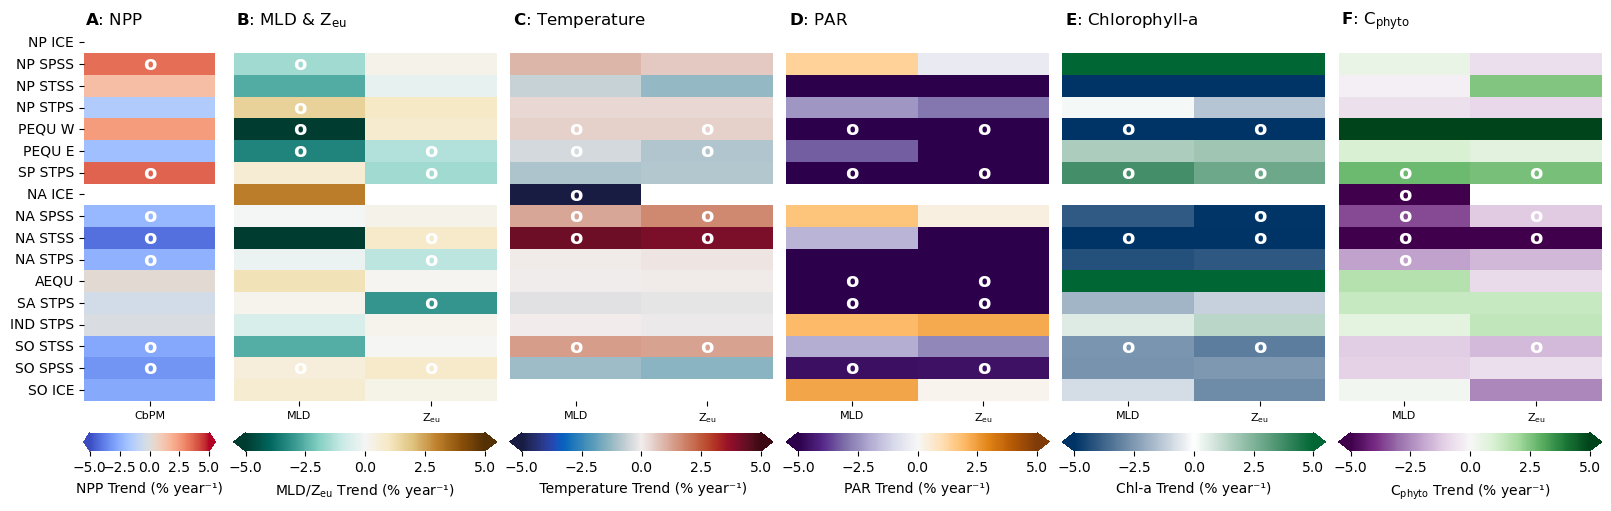

In [25]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b], join='outer', compat='no_conflicts')

threshold_date = np.datetime64('2026-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

sci_criteria = 0.70

ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
cbpm_biomes = calculate_trends_biomes(ds_cbpm, 'WESTBERRY_CBPM_INT', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_mld = ds1[['DATETIME', 'BIOME', 'MLD']].to_dataframe().dropna().reset_index(drop=True)
mld_biomes = calculate_trends_biomes(ds_mld, 'MLD', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_zeu = ds1[['DATETIME', 'BIOME', 'ZEU']].to_dataframe().dropna().reset_index(drop=True)
zeu_biomes = calculate_trends_biomes(ds_zeu, 'ZEU', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_chla = ds1[['DATETIME', 'BIOME', 'MLD_CHLA']].to_dataframe().dropna().reset_index(drop=True)
chla_biomes = calculate_trends_biomes(ds_chla, 'MLD_CHLA', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_cphyto = ds1[['DATETIME', 'BIOME', 'MLD_CPHYTO']].to_dataframe().dropna().reset_index(drop=True)
cphyto_biomes = calculate_trends_biomes(ds_cphyto, 'MLD_CPHYTO', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_temp = ds1[['DATETIME', 'BIOME', 'MLD_TEMP']].to_dataframe().dropna().reset_index(drop=True)
temp_biomes = calculate_trends_biomes(ds_temp, 'MLD_TEMP', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_par = ds1[['DATETIME', 'BIOME', 'MLD_DOWNWELLING_PAR']].to_dataframe().dropna().reset_index(drop=True)
par_biomes = calculate_trends_biomes(ds_par, 'MLD_DOWNWELLING_PAR', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_chla = ds1[['DATETIME', 'BIOME', 'ZEU_CHLA']].to_dataframe().dropna().reset_index(drop=True)
chla_biomes2 = calculate_trends_biomes(ds_chla, 'ZEU_CHLA', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_cphyto = ds1[['DATETIME', 'BIOME', 'ZEU_CPHYTO']].to_dataframe().dropna().reset_index(drop=True)
cphyto_biomes2 = calculate_trends_biomes(ds_cphyto, 'ZEU_CPHYTO', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_temp = ds1[['DATETIME', 'BIOME', 'ZEU_TEMP']].to_dataframe().dropna().reset_index(drop=True)
temp_biomes2 = calculate_trends_biomes(ds_temp, 'ZEU_TEMP', quality_control=False, normalise=True, sci_criteria=sci_criteria)

ds_par = ds1[['DATETIME', 'BIOME', 'ZEU_DOWNWELLING_PAR']].to_dataframe().dropna().reset_index(drop=True)
par_biomes2 = calculate_trends_biomes(ds_par, 'ZEU_DOWNWELLING_PAR', quality_control=False, normalise=True, sci_criteria=sci_criteria)

vmin = -5
vmax = 5

bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

# Setup figure and grid
fig = plt.figure(figsize=[16, 5], constrained_layout=True)
gs = plt.GridSpec(2, 6, figure=fig, width_ratios=[0.5, 1, 1, 1, 1, 1], height_ratios=[1, 0.05])

# Axes in top row (row 0), columns 0 to 5
axes = [fig.add_subplot(gs[0, i]) for i in range(6)]

# Colorbar axes in bottom row (row 1), same columns
caxes = [fig.add_subplot(gs[1, i]) for i in range(6)]

# Data for first heatmap (3 cols)
data1 = pd.DataFrame({
    'CbPM': cbpm_biomes.slope.values
}, index=bname)

pvals_stack = np.vstack([
    cbpm_biomes.p_value_hac.values
]).T

annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)

sns.heatmap(
    data1.astype(float),
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[0],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[0],
    yticklabels=bname,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': mld_biomes.slope.values,
    'Z$_{eu}$': zeu_biomes.slope.values
}, index=bname)

pvals_stack = np.vstack([
    mld_biomes.p_value_hac.values,
    zeu_biomes.p_value_hac.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1.astype(float),
    cmap=plt.cm.BrBG_r,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[1],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[1],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': temp_biomes.slope.values,
    'Z$_{eu}$': temp_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    temp_biomes.p_value_hac.values,
    temp_biomes2.p_value_hac.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1.astype(float),
    cmap=cmo.cm.balance,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[2],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[2],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': par_biomes.slope.values,
    'Z$_{eu}$': par_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    par_biomes.p_value_hac.values,
    par_biomes2.p_value_hac.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1.astype(float),
    cmap=plt.cm.PuOr_r,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[3],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[3],
    yticklabels=False,
    xticklabels=True)

colors = ["#003366", "#FFFFFF", "#006633"]  # dark blue, white, dark green (lighter than black)
chla_cmap = mpl.colors.LinearSegmentedColormap.from_list("BlueWhiteGreenLight", colors)

data1 = pd.DataFrame({
    'MLD': chla_biomes.slope.values,
    'Z$_{eu}$': chla_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    chla_biomes.p_value_hac.values,
    chla_biomes2.p_value_hac.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1.astype(float),
    cmap=chla_cmap,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[4],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[4],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': cphyto_biomes.slope.values,
    'Z$_{eu}$': cphyto_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    cphyto_biomes.p_value_hac.values,
    cphyto_biomes2.p_value_hac.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1.astype(float),
    cmap=plt.cm.PRGn,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[5],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[5],
    yticklabels=False,
    xticklabels=True)

# Add colorbar labels rotated 270 degrees
cbar_labels = [
    "NPP Trend (% year⁻¹)", "MLD/Z$_{eu}$ Trend (% year⁻¹)", " Temperature Trend (% year⁻¹)",
    "PAR Trend (% year⁻¹)", "Chl-a Trend (% year⁻¹)", "C$_{phyto}$ Trend (% year⁻¹)"]

for cax, label in zip(caxes, cbar_labels):
    cax.set_xlabel(label, fontsize=10, labelpad=5, ha='center')
    cax.set_xticks(np.arange(-5, 7.5, 2.5))

for ax in axes:
    plt.setp(ax.get_xticklabels(), fontsize=8, rotation=0)

axes[0].text(0.01, 1.02, r'$\bf{{A}}$: NPP', transform=axes[0].transAxes, fontsize=12)
axes[1].text(0.01, 1.02, r'$\bf{{B}}$: MLD & Z$_{eu}$', transform=axes[1].transAxes, fontsize=12)
axes[2].text(0.01, 1.02, r'$\bf{{C}}$: Temperature', transform=axes[2].transAxes, fontsize=12) 
axes[3].text(0.01, 1.02, r'$\bf{{D}}$: PAR', transform=axes[3].transAxes, fontsize=12) 
axes[4].text(0.01, 1.02, r'$\bf{{E}}$: Chlorophyll-a', transform=axes[4].transAxes, fontsize=12) 
axes[5].text(0.01, 1.02, r'$\bf{{F}}$: C$_{phyto}$', transform=axes[5].transAxes, fontsize=12) 

plt.show()

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_04.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_04.eps", bbox_inches='tight', dpi=300)

### Figure 5

In [43]:
biomes = xr.open_dataset(f'{resdir}/Mean_Biomes_25KM.nc').MeanBiomes

fname = '../../../Projects/Satellite NPP Data Product/data/output/Westberry-CbPM/1998_2025_NPP_WESTBERRY_CBPM_25KM_8D_HADLEY.nc'
sat_cbpm = xr.open_dataset(fname).sel(time=slice('2010-01-01', '2025-12-31'))
sat_cbpm['biomes'] = biomes

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b], join='outer', compat='no_conflicts')

threshold_date = np.datetime64('2026-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

df_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT', 
                'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().dropna().reset_index(drop=True)

sat_cbpm_resampled = []

for _, d in tqdm(df_cbpm.iterrows(), total=df_cbpm.shape[0]):
    sel = sat_cbpm.sel(
        lat=d.LATITUDE,
        lon=d.LONGITUDE,
        time=d.DATETIME,
        method='nearest',
    )
    sat_cbpm_resampled.append(sel['Westberry-CbPM'].item())

df_cbpm['WESTBERRY_CBPM_SAT'] = np.array(sat_cbpm_resampled, dtype=float)


100%|████████████████████████████████████████████████████████████████████████████| 44618/44618 [01:06<00:00, 673.16it/s]


In [44]:
cbpm_biomes = calculate_trends_biomes(df_cbpm, 'WESTBERRY_CBPM_INT', 
                                       quality_control=False, normalise=False, 
                                       sci_criteria=0.70)

cbpm_sat_resampled_biomes = calculate_trends_biomes(df_cbpm, 'WESTBERRY_CBPM_SAT', 
                                                     quality_control=False, normalise=False,
                                                      sci_criteria=0.70)

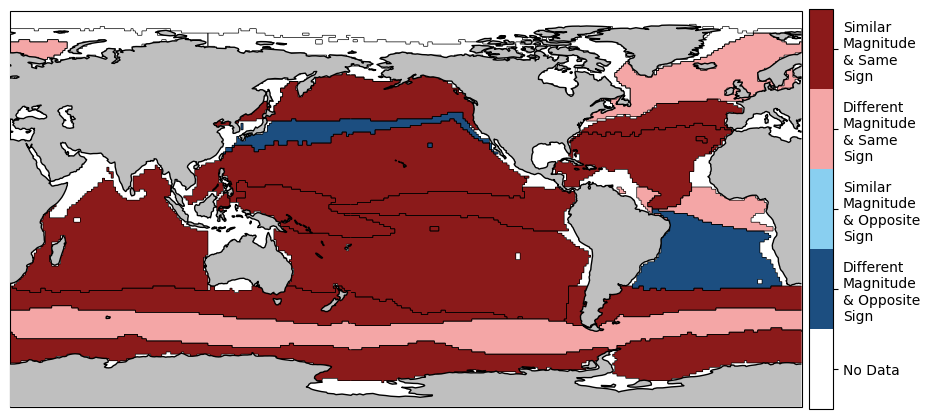

In [45]:
result_cbpm = compare_trends(cbpm_biomes, cbpm_sat_resampled_biomes)

biomes = xr.open_dataset(f'{resdir}/Mean_Biomes_25KM.nc')
biomes_array = biomes['MeanBiomes'].values
unique_values = np.unique(biomes_array)
unique_values = unique_values[:-1]
lats = biomes['lat'].values
lons = biomes['lon'].values
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

def make_biome_to_slope(lookup_array):
    def biome_to_slope(biome):
        if np.isnan(biome):
            return np.nan
        biome_int = int(biome)
        if biome_int < 0 or biome_int >= len(lookup_array):
            return np.nan
        return lookup_array[biome_int]
    return biome_to_slope

biome_class_map = dict(zip(range(1, 18), result_cbpm.classification_code))

max_biome = int(max(biome_class_map)) + 1
lookup_array = np.full(18, np.nan)
for biome, slope in biome_class_map.items():
    lookup_array[int(biome)] = slope

cbpm_cats = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

colors = [
    '#FFFFFF',  # 0 Unclassified
    '#1C4E80',  # 1 Sig. & Opposite Sign (dark blue)
    '#89CFF0',  # 2 Not Sig. & Opposite Sign (light blue)
    '#F4A6A6',  # 3 Sig. & Same Sign (light red)
    '#8B1A1A'   # 4 Not Sig. & Same Sign (dark red)
]

# Create the colormap
cmap = mpl.colors.ListedColormap(colors)

fig = plt.figure(figsize=[8, 5], constrained_layout=True)
gs = plt.GridSpec(1, 1, figure=fig)

ax = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree(central_longitude=-155))
ax.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax.set_global()

im = cbpm_cats.plot(ax=ax, cmap=cmap, add_colorbar=False, vmin=0, vmax=5, transform=ccrs.PlateCarree())
for value in unique_values:
    mask = biomes_array == value
    ax.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

cbar_ax = fig.add_axes([1.004, 0.1, 0.03, 0.80])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(0.5, 5.5, 1))
cbar.set_ticklabels([
    'No Data',
    'Different\nMagnitude\n& Opposite\nSign',
    'Similar\nMagnitude\n& Opposite\nSign',
    'Different\nMagnitude\n& Same\nSign',
    'Similar\nMagnitude\n& Same\nSign'
])

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_05.png", bbox_inches='tight', dpi=300)
#fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_05.eps", bbox_inches='tight', dpi=300)

In [46]:
cbpm_sat_resampled_biomes = calculate_trends_biomes(df_cbpm, 'WESTBERRY_CBPM_SAT', 
                                                     quality_control=False, normalise=True,
                                                      sci_criteria=0.70)
cbpm_sat_resampled_biomes

,slope,intercept,slope_se_hac,p_value_hac,r_squared,f_value,n_years,nw_lag_used,lag1_autocorr,sigma_noise,years_needed_detect,detection_feasible,sci_mean,sci_std,biome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,1.13669,0.91825,0.006256,0.102607,0.244886,2.918723,11,2,-0.037245,0.107445,9.666089,True,0.725179,0.304955,2
2,-3.698906,1.11699,0.009964,0.013823,0.47858,4.589191,7,2,-0.331416,0.090667,3.20287,True,0.741675,0.302772,3
3,-0.983511,1.066484,0.011569,0.413373,0.094723,1.150976,13,2,0.505383,0.140011,18.867956,False,0.913236,0.204709,4
4,1.535119,0.965019,0.025897,0.595039,0.021346,0.065435,5,2,-0.70504,0.178791,6.345813,False,0.735542,0.140662,5
5,-2.272246,1.08671,0.010146,0.066387,0.455476,5.01879,8,2,0.229451,0.063606,5.144484,True,0.890307,0.217747,6
6,3.868457,0.79508,0.012054,0.009345,0.419779,7.234822,12,2,0.126107,0.158746,6.182447,True,0.978091,0.050539,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
8,-0.304552,1.020069,0.00324,0.371753,0.037278,0.348492,11,2,-0.278124,0.063085,13.819153,False,0.730235,0.280913,9
9,-3.098368,1.164688,0.010962,0.025537,0.254526,2.389996,9,2,-0.072879,0.214628,7.671957,True,0.757424,0.257556,10


In [47]:
cbpm_sat_resampled_biomes = calculate_trends_biomes(df_cbpm, 'WESTBERRY_CBPM_SAT', 
                                                     quality_control=False, normalise=False,
                                                      sci_criteria=0.70)
cbpm_sat_resampled_biomes

,slope,intercept,slope_se_hac,p_value_hac,r_squared,f_value,n_years,nw_lag_used,lag1_autocorr,sigma_noise,years_needed_detect,detection_feasible,sci_mean,sci_std,biome
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,8.308528,671.18657,4.572928,0.102607,0.244886,2.918723,11,2,-0.037245,78.536073,9.666089,True,0.725179,0.304955,2
2,-20.940823,632.368074,5.641069,0.013823,0.47858,4.589191,7,2,-0.331416,51.329605,3.20287,True,0.741675,0.302772,3
3,-4.255457,461.446853,5.00564,0.413373,0.094723,1.150976,13,2,0.505383,60.580157,18.867956,False,0.913236,0.204709,4
4,10.636206,668.621708,17.942699,0.595039,0.021346,0.065435,5,2,-0.70504,123.876615,6.345813,False,0.735542,0.140662,5
5,-21.551246,1030.695956,9.622968,0.066387,0.455476,5.01879,8,2,0.229451,60.327552,5.144484,True,0.890307,0.217747,6
6,16.613175,341.448745,5.176752,0.009345,0.419779,7.234822,12,2,0.126107,68.173977,6.182447,True,0.978091,0.050539,7
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.0
8,-1.965392,658.28889,2.090813,0.371753,0.037278,0.348492,11,2,-0.278124,40.711088,13.819153,False,0.730235,0.280913,9
9,-21.016467,790.016707,7.435713,0.025537,0.254526,2.389996,9,2,-0.072879,145.583556,7.671957,True,0.757424,0.257556,10


## Supplementary Figures

### Figure S01

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


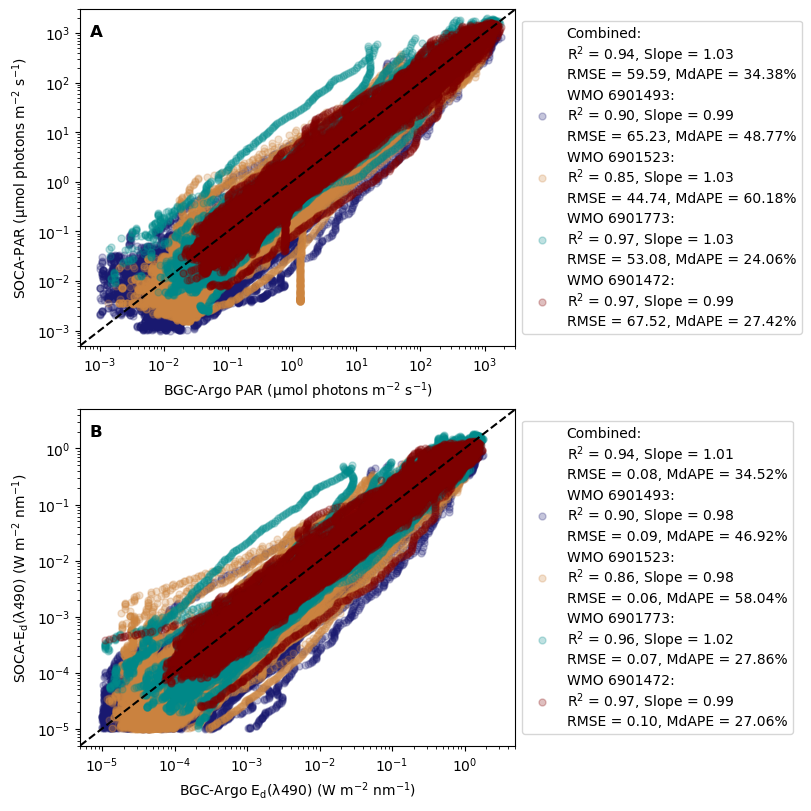

In [48]:
soca_globcolour_par_data = pd.read_csv('../DATA/SOCA VALIDATION/soca_globcolour_par_data.csv')
soca_globcolour_par_data1 = soca_globcolour_par_data.loc[
    soca_globcolour_par_data["WMO"].eq(6901472)
]

soca_globcolour_par_data2 = soca_globcolour_par_data.loc[
    soca_globcolour_par_data["WMO"].eq(6901523)
]

soca_globcolour_par_data3 = soca_globcolour_par_data.loc[
    soca_globcolour_par_data["WMO"].eq(6901493)
]

soca_globcolour_par_data4 = soca_globcolour_par_data.loc[
    soca_globcolour_par_data["WMO"].eq(6901773)
]

soca_globcolour_ed490_data = pd.read_csv('../DATA/SOCA VALIDATION/soca_globcolour_ed490_data.csv')
soca_globcolour_ed490_data1 = soca_globcolour_ed490_data.loc[
    soca_globcolour_ed490_data["WMO"].eq(6901472)
]

soca_globcolour_ed490_data2 = soca_globcolour_ed490_data.loc[
    soca_globcolour_ed490_data["WMO"].eq(6901523)
]

soca_globcolour_ed490_data3 = soca_globcolour_ed490_data.loc[
    soca_globcolour_ed490_data["WMO"].eq(6901493)
]

soca_globcolour_ed490_data4 = soca_globcolour_ed490_data.loc[
    soca_globcolour_ed490_data["WMO"].eq(6901773)
]

# Prepare data groups
data_groups = [
    {
        "ax": 0,
        "title": r'$\bf{A}$',
        "datasets": [
            ("Combined", soca_globcolour_par_data, 'w'),
            ("WMO 6901493", soca_globcolour_par_data3, plot_colors[0]),
            ("WMO 6901523", soca_globcolour_par_data2, plot_colors[1]),
            ("WMO 6901773", soca_globcolour_par_data4, plot_colors[2]),
            ("WMO 6901472", soca_globcolour_par_data1, plot_colors[3]),
        ],
        "compute_stats": True,
    },
    {
        "ax": 1,
        "title": r'$\bf{B}$',
        "datasets": [
            ("Combined", soca_globcolour_ed490_data, 'w'),
            ("WMO 6901493", soca_globcolour_ed490_data3, plot_colors[0]),
            ("WMO 6901523", soca_globcolour_ed490_data2, plot_colors[1]),
            ("WMO 6901773", soca_globcolour_ed490_data4, plot_colors[2]),
            ("WMO 6901472", soca_globcolour_ed490_data1, plot_colors[3]),
        ],
        "compute_stats": True,
    }
]

fig = plt.figure(figsize=[8, 8], constrained_layout=True)
gs = plt.GridSpec(2, 1, figure=fig)
axes = [fig.add_subplot(gs[i, :]) for i in range(2)]

# Main loop for plotting
for group in data_groups:
    ax = axes[group["ax"]]
    for label, data, color in group["datasets"]:
        x, y = data['measured'], data['modelled']
        if group["compute_stats"]:
            rmse = np.sqrt(mean_squared_error(x, y))
            mape = np.median(np.abs((x - y) / x)) * 100
            r2 = r2_score(np.log10(x), np.log10(y))
            slope, inter = np.polyfit(np.log10(x), np.log10(y), 1)
            label = f'{label}:\nR$^2$ = {r2:.2f}, Slope = {slope:.2f}\nRMSE = {rmse:.2f}, MdAPE = {mape:.2f}%'
        else:
            label = f'{label}'
        ax.plot(x, y, 'o', markersize=5, alpha=0.25, lw=0, c=color, label=label)

    # Reference 1:1 line
    if group["ax"] == 0:
        ax.plot([5e-4, 3000], [5e-4, 3000], c='k', ls='--')
        ax.set_xlim(5e-4, 3000)
        ax.set_ylim(5e-4, 3000)
        ax.set_ylabel("SOCA-PAR (μmol photons m$^{-2}$ s$^{-1}$)")
        ax.set_xlabel("BGC-Argo PAR (μmol photons m$^{-2}$ s$^{-1}$)")
    else:
        ax.plot([5e-6, 5], [5e-6, 5], c='k', ls='--')
        ax.set_xlim(5e-6, 5)
        ax.set_ylim(5e-6, 5)
        ax.set_ylabel("SOCA-E$_d$(λ490) (W m$^{-2}$ nm$^{-1}$)")
        ax.set_xlabel("BGC-Argo E$_d$(λ490) (W m$^{-2}$ nm$^{-1}$)")

    # Axis settings
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)
    ax.text(0.02, 0.92, group["title"], transform=ax.transAxes, fontsize=12)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S01.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S01.eps", bbox_inches='tight', dpi=300)

### Figure S02

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


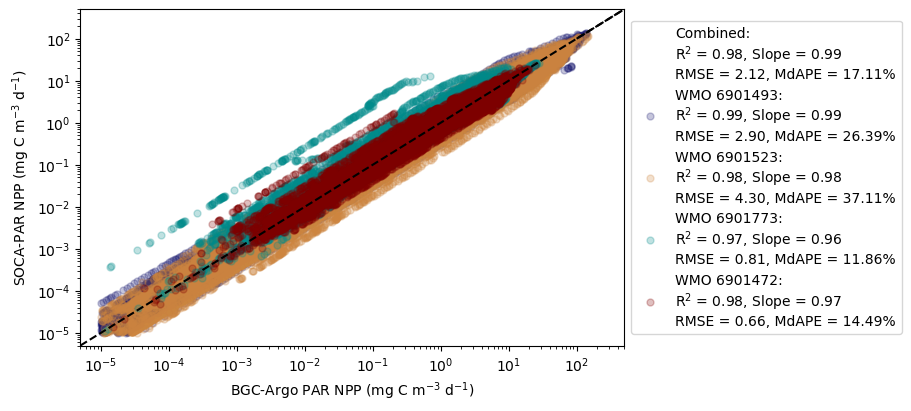

In [50]:
soca_globcolour_westberry_cbpm_data = pd.read_csv('../DATA/SOCA VALIDATION/soca_globcolour_westberry_cbpm_data.csv')
soca_globcolour_westberry_cbpm_data1 = soca_globcolour_westberry_cbpm_data.loc[
    soca_globcolour_westberry_cbpm_data["WMO"].eq(6901472)
]

soca_globcolour_westberry_cbpm_data2 = soca_globcolour_westberry_cbpm_data.loc[
    soca_globcolour_westberry_cbpm_data["WMO"].eq(6901523)
]

soca_globcolour_westberry_cbpm_data3 = soca_globcolour_westberry_cbpm_data.loc[
    soca_globcolour_westberry_cbpm_data["WMO"].eq(6901493)
]

soca_globcolour_westberry_cbpm_data4 = soca_globcolour_westberry_cbpm_data.loc[
    soca_globcolour_westberry_cbpm_data["WMO"].eq(6901773)
]

# Prepare data groups
data_groups = [
    {
        "ax": 0,
        "title": '',
        "datasets": [
            ("Combined", soca_globcolour_westberry_cbpm_data, 'w'),
            ("WMO 6901493", soca_globcolour_westberry_cbpm_data3, plot_colors[0]),
            ("WMO 6901523", soca_globcolour_westberry_cbpm_data2, plot_colors[1]),
            ("WMO 6901773", soca_globcolour_westberry_cbpm_data4, plot_colors[2]),
            ("WMO 6901472", soca_globcolour_westberry_cbpm_data1, plot_colors[3]),
        ],
        "compute_stats": True,
    },
]

fig = plt.figure(figsize=[9, 4], constrained_layout=True)
gs = plt.GridSpec(1, 1, figure=fig)
axes = [fig.add_subplot(gs[i, :]) for i in range(1)]

for group in data_groups:
    ax = axes[group["ax"]]
    for label, data, color in group["datasets"]:
        x = np.asarray(data["measured"], dtype=float)
        y = np.asarray(data["modelled"], dtype=float)

        # Common mask: finite and positive for log10 and MAPE
        mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
        x = x[mask]
        y = y[mask]

        if group["compute_stats"] and x.size > 1:
            # ---- Linear-space metrics ----
            rmse = np.sqrt(mean_squared_error(x, y))
            mape = np.median(np.abs((x - y) / x)) * 100  # % MdAPE

            # ---- Log–log regression & R² ----
            xlog = np.log10(x)
            ylog = np.log10(y)

            slope, inter = np.polyfit(xlog, ylog, 1)
            ylog_hat = slope * xlog + inter

            # R² of the fitted regression line in log space
            r2 = r2_score(ylog, ylog_hat)

            label = (
                f"{label}:\n"
                f"R$^2$ = {r2:.2f}, Slope = {slope:.2f}\n"
                f"RMSE = {rmse:.2f}, MdAPE = {mape:.2f}%")
        else:
            label = f"{label}"

        ax.plot(
            x, y,
            "o", markersize=5, alpha=0.25, lw=0,
            c=color, label=label)
        
    # Reference 1:1 line
    ax.plot([100, 6000], [100, 6000], c='k', ls='--')

    # Axis settings
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel("BGC-Argo PAR NPP (mg C m$^{-3}$ d$^{-1}$)")
    ax.set_ylabel("SOCA-PAR NPP (mg C m$^{-3}$ d$^{-1}$)")
    # Reference 1:1 line
    ax.plot([0.000005, 500], [0.000005, 500], c='k', ls='--')
    ax.set_xlim(0.000005, 500)
    ax.set_ylim(0.000005, 500)
    ax.text(0.02, 0.92, group["title"], transform=ax.transAxes, fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S02.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S02.eps", bbox_inches='tight', dpi=300)

### Figure S03

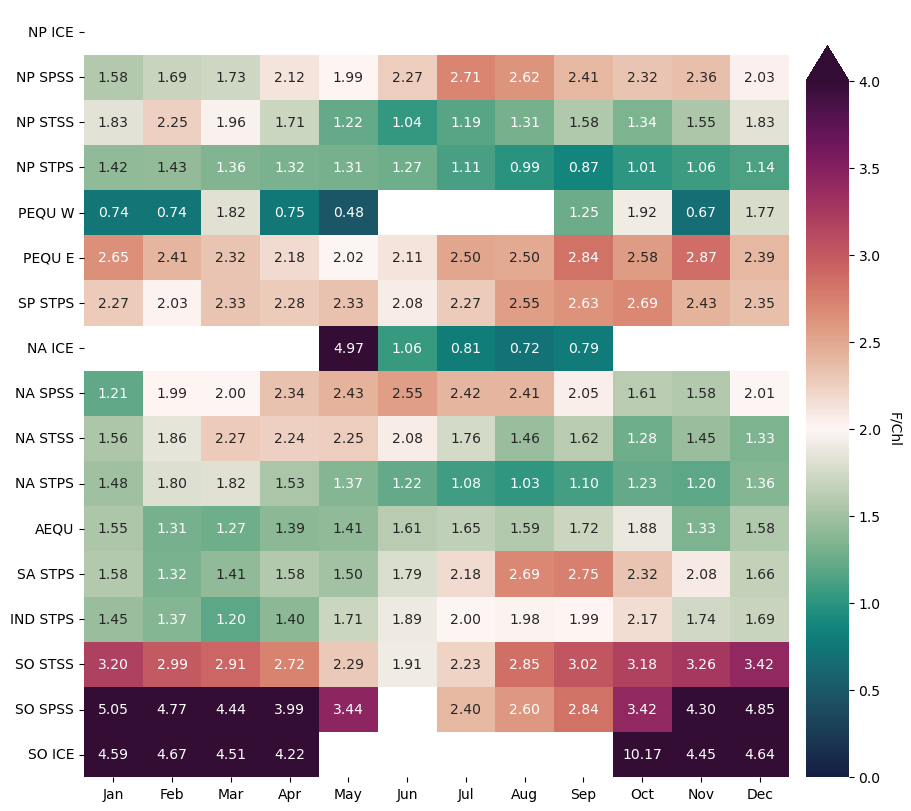

In [20]:
fname = f'../DATA/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_XING.csv'
xing_fchl = pd.read_csv(fname, index_col='BIOME').reindex(range(1,18))

bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']
month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig = plt.figure(figsize=[10, 8], constrained_layout=True)
gs = plt.GridSpec(1, 2, figure=fig, width_ratios=[1, 0.3])

ax0 = fig.add_subplot(gs[0, 0])
ax_cbar = fig.add_subplot(gs[0, 1]) 

sns.heatmap(
    1/xing_fchl,
    cmap=cmo.cm.curl,
    vmin=0,
    vmax=4,
    center=2,
    annot=True,
    fmt=".2f", 
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={'extend':'max'},
    ax=ax0)

ax0.set_yticklabels(bname, rotation=0)
ax0.set_xticklabels(month, rotation=0)
ax0.set_ylabel('')

ax_cbar.set_ylabel('F/Chl', rotation=270, labelpad=15)
pos = ax_cbar.get_position()
ax_cbar.set_position([pos.x0+0.05, pos.y0, pos.width * 0.2, pos.height])

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S03.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S03.eps", bbox_inches='tight', dpi=300)

### Figure S04

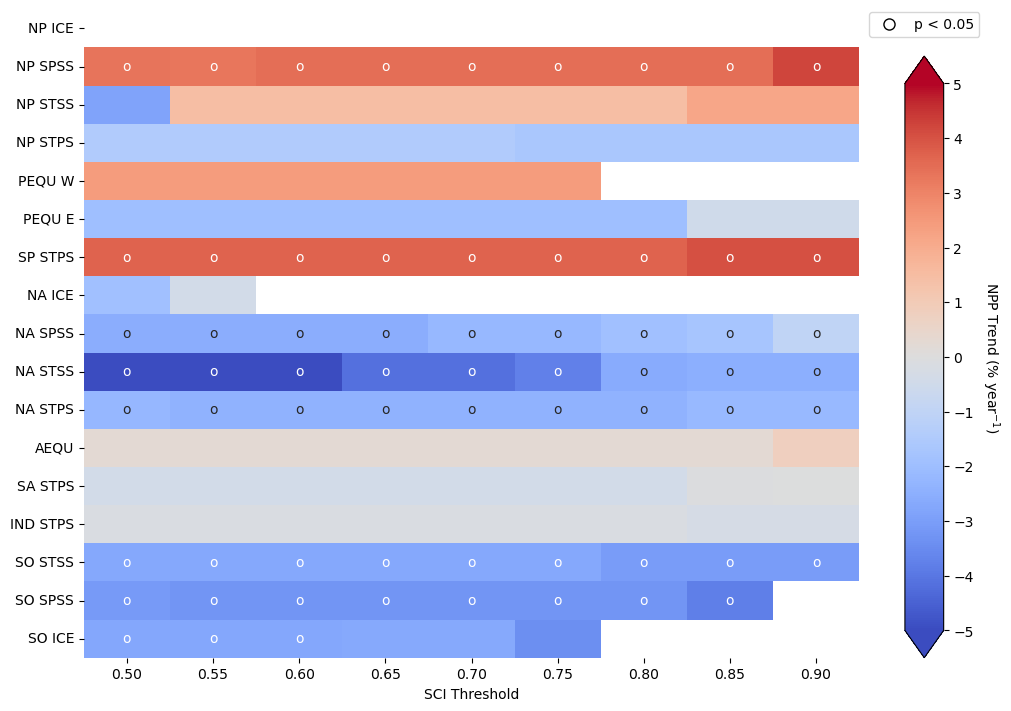

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [21]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b], join='outer', compat='no_conflicts')

threshold_date = np.datetime64('2026-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

thresholds = np.arange(0.5, 0.95, 0.05)  # from 0 to 0.8

ds_cbpm = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM_INT']].to_dataframe().dropna().reset_index(drop=True)
sensitivity_cbpm = run_sci_sensitivity_analysis(ds_cbpm, var='WESTBERRY_CBPM_INT', normalise=True, thresholds=thresholds)

bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

fig = plt.figure(figsize=[10, 7], constrained_layout=True)
gs = plt.GridSpec(2, 2, figure=fig, width_ratios=[1, 0.05], height_ratios=[0.05, 1])

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')
sig_marker = plt.Line2D([0], [0],
                    lw=0,
                    marker='o',
                    markerfacecolor='w',
                    markeredgecolor='k',
                    markersize=8,
                    label='p < 0.05')

legend_handles = [sig_marker]

# Custom legend
ax_legend.legend(handles=legend_handles, loc='center', ncol=1, fontsize=10)

# Create axes for colorbar (small left column)
cax = fig.add_subplot(gs[1, 1])

# Axes for heatmaps
ax0 = fig.add_subplot(gs[:, 0])

# Common cmap and norm for all heatmaps
cmap = 'coolwarm'
vmin, vmax = -5, 5
nor = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for ax, ds in zip([ax0], [sensitivity_cbpm]):
    df_plot = ds.reset_index()
    pivot = df_plot.pivot(index='biome', columns='sci_criteria', values='slope').astype(float)
    mask = df_plot.pivot(index='biome', columns='sci_criteria', values='p_value_hac').astype(float) < 0.05
    annot = mask.replace({True: 'o', False: ''})
    
    sns.heatmap(
        pivot, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
        annot=annot, fmt='',
        cbar=False,
        ax=ax
    )


ax0.set_yticklabels(bname, rotation=0)
ax0.set_ylabel('')
ax0.set_xlabel('SCI Threshold')

ax0.set_xticklabels(['0.50' ,'0.55' ,'0.60', '0.65', '0.70', '0.75', '0.80', '0.85', '0.90'], rotation=0)

# Create a ScalarMappable for the colorbar with the same cmap and norm
sma = mpl.cm.ScalarMappable(cmap=cmap, norm=nor)
sma.set_array([])  # dummy array for colorbar

# Add the colorbar on the left axis, vertical orientation
fig.colorbar(sma, cax=cax, orientation='vertical', extend='both', ticks=np.arange(-5, 6, 1))

# Optionally, set colorbar label
cax.set_ylabel('NPP Trend (% year$^{-1}$)', rotation=270, labelpad=20)

plt.show()

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S04.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S04.eps", bbox_inches='tight', dpi=300)